In [1]:
!pip install monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 28.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 94.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 75.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 80.8 MB/s eta 0:00:00:00:0100:01
  Attempting unins

In [4]:
import os

# Get the list of all files and directories in the working directory
contents = os.listdir('/kaggle/working')

# Print the list
print("Contents of /kaggle/working:")
if not contents:
    print("❌ The directory is empty.")
else:
    for item in contents:
        print(f" - {item}")

Contents of /kaggle/working:
 - state.db
 - .virtual_documents
 - MRI_best_model.pkl
 - MRI_model_checkpoint.pkl
 - MRI_best_model.pth


In [3]:
import os

OUTPUT_DIR = '/kaggle/working/'
checkpoint_path = os.path.join(OUTPUT_DIR, "MRI_model_checkpoint.pkl")
best_model_path = os.path.join(OUTPUT_DIR, "MRI_best_model.pkl")
old_model_path = os.path.join(OUTPUT_DIR, "final_best_model.pkl")

# List of files to delete
files_to_delete = [checkpoint_path, best_model_path, old_model_path]

print("Starting cleanup...")
for file_path in files_to_delete:
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"✅ Deleted: {file_path}")
    else:
        print(f"⏩ Skipped: {file_path} (File not found)")

print("Cleanup complete.")

Starting cleanup...
✅ Deleted: /kaggle/working/MRI_model_checkpoint.pkl
✅ Deleted: /kaggle/working/MRI_best_model.pkl
⏩ Skipped: /kaggle/working/final_best_model.pkl (File not found)
Cleanup complete.


In [4]:
import os
import pickle

# Set the path to the directory with your new preprocessed files
PREPROCESSED_DIR = '/kaggle/input/new-isles/new_preprocessed'

truncated_files = []

# Get a list of all the preprocessed files
try:
    all_files = [f for f in os.listdir(PREPROCESSED_DIR) if f.endswith('_processed.pkl')]
    if not all_files:
        print("❌ No preprocessed files found.")
    else:
        print(f"✅ Found {len(all_files)} files. Checking for integrity...")
        for filename in all_files:
            file_path = os.path.join(PREPROCESSED_DIR, filename)
            try:
                with open(file_path, 'rb') as f:
                    pickle.load(f)
            except (pickle.UnpicklingError, EOFError):
                print(f"❌ Corrupted file found: {filename}")
                truncated_files.append(filename)
                
except FileNotFoundError:
    print(f"❌ Directory not found: {PREPROCESSED_DIR}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

# Print a summary of the corrupted files
if truncated_files:
    print("\n--- Summary ---")
    print(f"Found {len(truncated_files)} corrupted files. You need to re-run preprocessing for these cases:")
    for file in truncated_files:
        print(f" - {file}")
else:
    print("\n✅ All files are intact. No corrupted files found.")

✅ Found 250 files. Checking for integrity...

✅ All files are intact. No corrupted files found.


In [1]:
import os
import glob

# Define the directory where models are saved, consistent with your training script
OUTPUT_DIR = '/kaggle/working/'

print("--- Starting Cleanup of Existing Fold Models ---")

# Find all files that match the fold model naming pattern
fold_model_files = glob.glob(os.path.join(OUTPUT_DIR, "MRI_best_model_fold_*.pkl"))

if not fold_model_files:
    print("No existing fold models found to delete.")
else:
    for file_path in fold_model_files:
        try:
            os.remove(file_path)
            print(f"✅ Deleted: {os.path.basename(file_path)}")
        except OSError as e:
            print(f"❌ Error deleting file {os.path.basename(file_path)}: {e}")

print("\n--- Cleanup Complete ---")
print("You can now run the training cell to retrain all folds from scratch.")

--- Starting Cleanup of Existing Fold Models ---
✅ Deleted: MRI_best_model_fold_2.pkl
✅ Deleted: MRI_best_model_fold_5.pkl
✅ Deleted: MRI_best_model_fold_4.pkl
✅ Deleted: MRI_best_model_fold_1.pkl
✅ Deleted: MRI_best_model_fold_3.pkl

--- Cleanup Complete ---
You can now run the training cell to retrain all folds from scratch.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import numpy as np
import os
import pickle
from tqdm import tqdm
from monai.networks.nets import SegResNet
from monai.losses import DiceLoss, FocalLoss
from monai.transforms import (
    Compose,
    ToTensord,
    RandCropByPosNegLabeld,
    RandFlipd,
    RandRotated,
    RandZoomd,
    RandAdjustContrastd,
    RandGaussianNoised,
)
from sklearn.model_selection import KFold

# --- Set up Kaggle Paths ---
PREPROCESSED_DIR = '/kaggle/input/isles-22/ISLES_preprocessed'
OUTPUT_DIR = '/kaggle/working/'

# --- Memory-efficient dataset class (No changes) ---
class StrokeDataset(Dataset):
    def __init__(self, case_files):
        self.case_files = case_files
    def __len__(self):
        return len(self.case_files)
    def __getitem__(self, idx):
        with open(self.case_files[idx], 'rb') as f:
            data = pickle.load(f)
        image = torch.FloatTensor(data['image'])
        label = torch.FloatTensor(data['label'])
        if label.dim() == 3:
            label = label.unsqueeze(0)
        return image, label

# --- Combined Loss Function (No changes) ---
class CombinedDiceFocalLoss(nn.Module):
    def __init__(self, dice_weight=0.5, focal_weight=0.5):
        super(CombinedDiceFocalLoss, self).__init__()
        self.dice_loss = DiceLoss(to_onehot_y=False, sigmoid=True)
        self.focal_loss = FocalLoss(to_onehot_y=False)
        self.dice_weight = dice_weight
        self.focal_weight = focal_weight
        self.foreground_weight = 2.0

    def forward(self, pred, target):
        dice_loss = self.dice_loss(pred, target)
        focal_loss = self.focal_loss(pred, target)
        weighted_dice_loss = dice_loss * self.foreground_weight
        
        return self.dice_weight * weighted_dice_loss + self.focal_weight * focal_loss

# --- Early Stopping Class (No changes) ---
class EarlyStopping:
    def __init__(self, patience=20, verbose=True, delta=0):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.best_score = None
        self.epochs_without_improvement = 0
        self.stop = False
    def __call__(self, val_loss):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.epochs_without_improvement += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.epochs_without_improvement} out of {self.patience}')
            if self.epochs_without_improvement >= self.patience:
                self.stop = True
        else:
            self.best_score = score
            self.epochs_without_improvement = 0

# --- Training and Validation Functions (No changes) ---
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    for i, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)
        
        with autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        
        running_loss += loss.item()

    return running_loss / len(loader)

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for i, (images, labels) in enumerate(loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
    return running_loss / len(loader)

# --- MODIFIED MAIN K-FOLD TRAINING LOOP ---
def main_kfold_training(all_files, num_epochs=50, n_splits=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    all_files = np.array(all_files) 
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for fold, (train_idx, val_idx) in enumerate(kf.split(all_files)):
        
        ### --- START OF MODIFICATION --- ###
        # Check if the final model for this fold already exists
        best_model_path = os.path.join(OUTPUT_DIR, f"MRI_best_model_fold_{fold+1}.pkl")
        if os.path.exists(best_model_path):
            print(f"\\n{'='*20}")
            print(f"--- ✅ Model for Fold {fold+1} already exists. Skipping. ---")
            print(f"{'='*20}\\n")
            continue # Skip to the next fold
        ### --- END OF MODIFICATION --- ###
            
        print(f"\\n{'='*20}")
        print(f"--- Starting Training for Fold {fold+1}/{n_splits} ---")
        print(f"{'='*20}\\n")

        train_files = all_files[train_idx].tolist()
        val_files = all_files[val_idx].tolist()

        print(f"Training on {len(train_files)} cases. Validating on {len(val_files)} cases.")
        
        train_transforms = Compose(
            [
                RandCropByPosNegLabeld(keys=["image", "label"], label_key="label", spatial_size=(96, 96, 96), pos=1.0, neg=0.0, num_samples=1, image_key="image"),
                RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
                RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
                RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
                RandRotated(keys=["image", "label"], range_x=(-15, 15), range_y=(-15, 15), range_z=(-15, 15), prob=0.5),
                RandZoomd(keys=["image", "label"], min_zoom=0.9, max_zoom=1.1, prob=0.5),
                RandAdjustContrastd(keys="image", prob=0.5, gamma=(0.5, 2.0)),
                RandGaussianNoised(keys="image", prob=0.5, std=(0.0, 0.01)),
                ToTensord(keys=["image", "label"]),
            ]
        )
        
        train_dataset = StrokeDataset(train_files)
        val_dataset = StrokeDataset(val_files)

        train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
        val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)
        
        model = SegResNet(spatial_dims=3, in_channels=2, out_channels=1, init_filters=16).to(device)
        criterion = CombinedDiceFocalLoss(dice_weight=0.5, focal_weight=0.5)
        optimizer = optim.AdamW(model.parameters(), lr=1e-4)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
        scaler = GradScaler('cuda')
        early_stopping = EarlyStopping(patience=20, verbose=True)
        
        best_val_loss = float('inf')
        
        for epoch in range(num_epochs):
            train_loss = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)
            val_loss = validate_one_epoch(model, val_loader, criterion, device)
            
            print(f"Fold {fold+1}/{n_splits} | Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
            
            scheduler.step(val_loss)
            early_stopping(val_loss)
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                with open(best_model_path, 'wb') as f:
                    pickle.dump(model.state_dict(), f)
                print(f"⭐ New best model for Fold {fold+1} saved with validation loss: {best_val_loss:.4f}")
            
            if early_stopping.stop:
                print(f"Early stopping triggered for Fold {fold+1}. Moving to next fold.")
                break
                
        print(f"\\n✅ Training complete for Fold {fold+1}.")
        print(f"Final best model for this fold saved to: {best_model_path}")

    print("\\n🎉 All K-Fold training runs are complete.")

# --- Main Execution Block ---
if __name__ == "__main__":
    try:
        all_case_ids = [f.replace('_processed.pkl', '') for f in os.listdir(PREPROCESSED_DIR) if f.endswith('_processed.pkl')]
        all_files = [os.path.join(PREPROCESSED_DIR, f'{case_id}_processed.pkl') for case_id in all_case_ids]

        if not all_files:
            print("❌ No preprocessed files found. Please check your data directory.")
        else:
            main_kfold_training(all_files, num_epochs=50, n_splits=5)

    except FileNotFoundError as e:
        print(f"❌ Error: A required file was not found. Please ensure the dataset is correctly mounted. Details: {e}")

<frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2025-10-02 04:03:04.066359: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759377784.089497     101 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759377784.096530     101 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


\n====================
--- ✅ Model for Fold 1 already exists. Skipping. ---
====================\n
\n====================
--- ✅ Model for Fold 2 already exists. Skipping. ---
====================\n
\n====================
--- ✅ Model for Fold 3 already exists. Skipping. ---
====================\n
\n====================
--- Starting Training for Fold 4/5 ---
====================\n
Training on 200 cases. Validating on 50 cases.
Fold 4/5 | Epoch 1/50 | Train Loss: 1.0087 | Val Loss: 0.9864
⭐ New best model for Fold 4 saved with validation loss: 0.9864
Fold 4/5 | Epoch 2/50 | Train Loss: 0.9900 | Val Loss: 0.9797
⭐ New best model for Fold 4 saved with validation loss: 0.9797
Fold 4/5 | Epoch 3/50 | Train Loss: 0.9786 | Val Loss: 0.9631
⭐ New best model for Fold 4 saved with validation loss: 0.9631
Fold 4/5 | Epoch 4/50 | Train Loss: 0.9711 | Val Loss: 0.9533
⭐ New best model for Fold 4 saved with validation loss: 0.9533
Fold 4/5 | Epoch 5/50 | Train Loss: 0.9644 | Val Loss: 0.9473
⭐ New bes

<frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2025-10-02 06:39:18.448942: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759387158.471554     101 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759387158.479159     101 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Found 5 models for ensembling.
✅ All 5 models loaded for ensembling.
Test cases: 38


Getting Ensemble Predictions: 100%|██████████| 38/38 [00:32<00:00,  1.16it/s]



--- Searching for optimal threshold ---
Threshold: 0.30, Mean Dice Score: 0.7874
Threshold: 0.35, Mean Dice Score: 0.7889
Threshold: 0.40, Mean Dice Score: 0.7898
Threshold: 0.45, Mean Dice Score: 0.7884
Threshold: 0.50, Mean Dice Score: 0.7863
Threshold: 0.55, Mean Dice Score: 0.7845
Threshold: 0.60, Mean Dice Score: 0.7802
Threshold: 0.65, Mean Dice Score: 0.7751
Threshold: 0.70, Mean Dice Score: 0.7706

✅ Best Threshold Found: 0.40 with Dice Score: 0.7898

--- Calculating final metrics using optimal threshold ---


/usr/local/lib/python3.11/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/usr/local/lib/python3.11/dist-packages/monai/metrics/utils.py:327: UserWarning: the ground truth of class 0 is all 0, this may result in nan/inf distance.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/monai/metrics/utils.py:332: UserWarning: the prediction of class 0 is all 0, this may result in nan/inf distance.
  warnings.warn(



Final Ensembled Test Set Performance (Threshold Tuned):
Mean Dice Score: 0.7898
Mean Jaccard Index (IoU): 0.6526
Precision: 0.8844
Recall: 0.8049
F1 Score: 0.8428
95th Percentile Hausdorff Distance (HD95): 8.5380


Using device: cuda
✅ Found 5 models for ensembling.
✅ All 5 models loaded successfully.

Found 250 total cases to process.
Using prediction threshold: 0.4


Extracting Biomarkers and Collecting EDA Stats: 100%|██████████| 250/250 [04:06<00:00,  1.01it/s]
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):



--- Extracted Biomarkers Summary (First 5 cases) ---
              case_id  predicted_lesion_volume_mm3
0  sub-strokecase0001                       2927.0
1  sub-strokecase0002                        924.0
2  sub-strokecase0003                      29123.0
3  sub-strokecase0004                       2042.0
4  sub-strokecase0005                       4323.0

✅ Biomarker data saved to: /kaggle/working/extracted_biomarkers.csv


--- Exploratory Data Analysis (from Ground Truth) ---

--- Lesion Prevalence ---
Total cases: 250
Positive cases (with lesion): 237
Prevalence: 94.80%


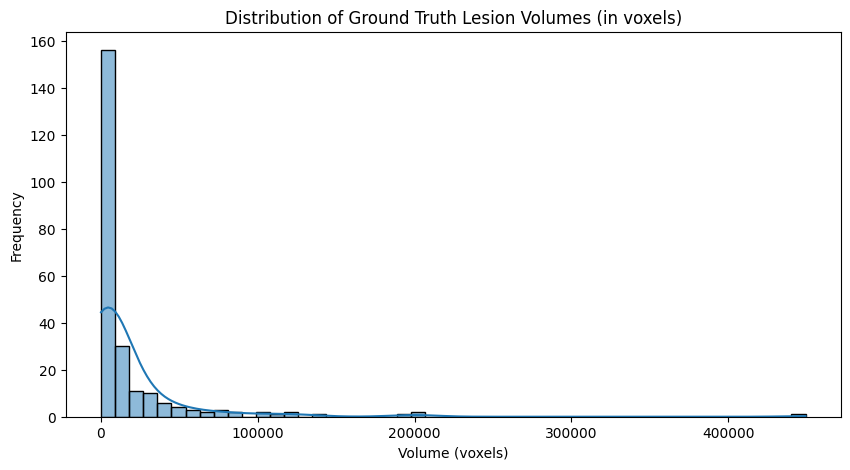

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


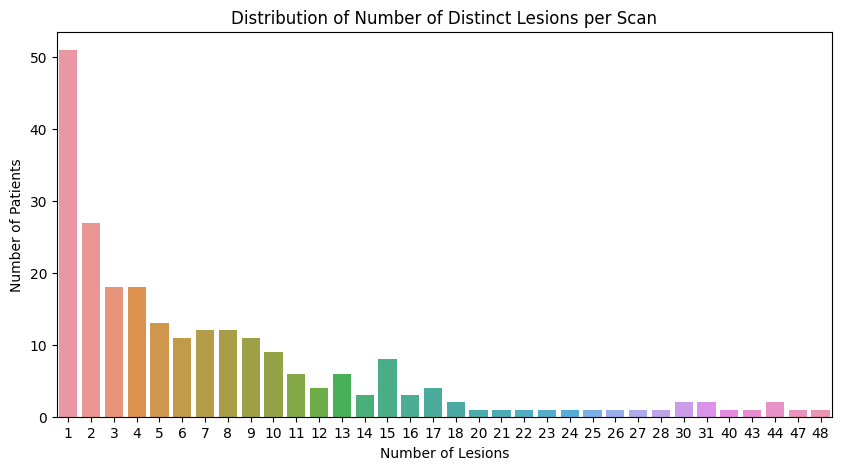


--- Lesion Location Heatmap ---


/tmp/ipykernel_101/3514702857.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


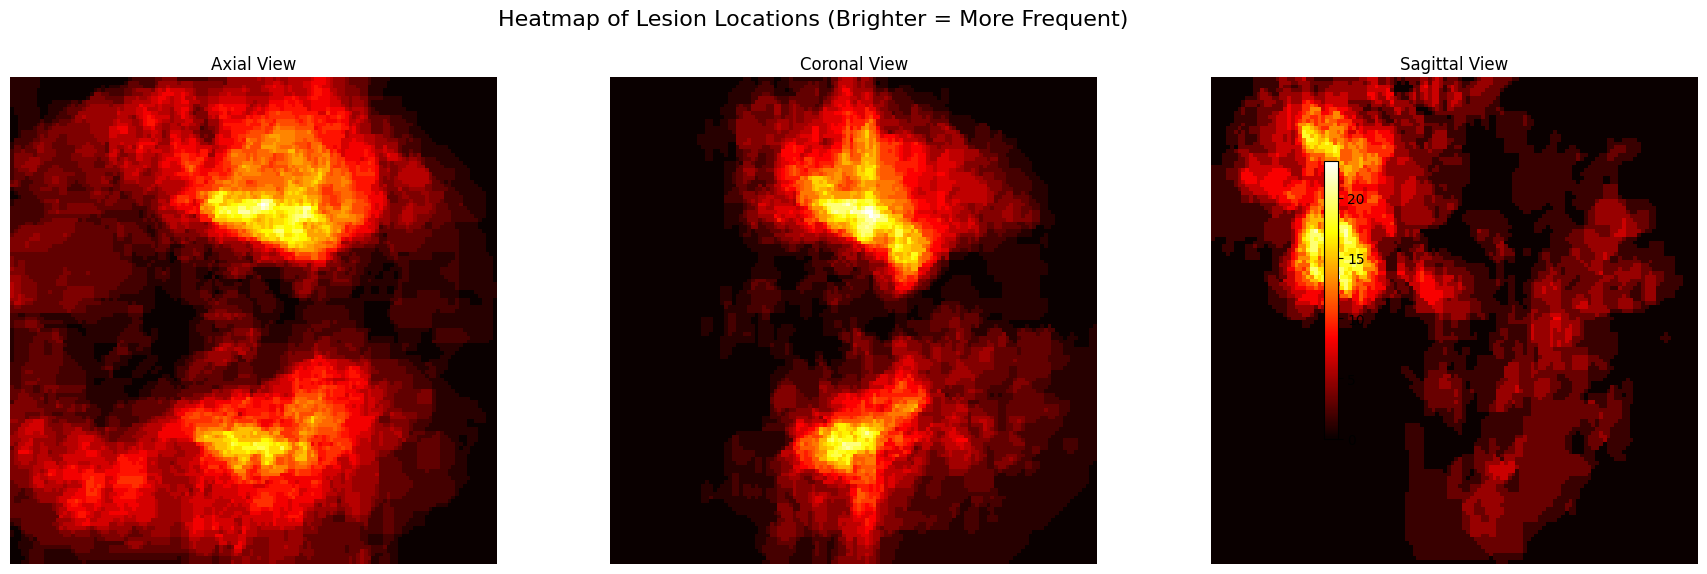

In [3]:
import torch
import torch.nn as nn
from monai.networks.nets import SegResNet
import numpy as np
import pandas as pd
import os
import pickle
import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import ndimage

# --- Set up Kaggle Paths ---
PREPROCESSED_DIR = '/kaggle/input/isles-22/ISLES_preprocessed'
OUTPUT_DIR = '/kaggle/working/'

# --- Main Execution Block ---
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- 1. Load All 5 Fold Models for Ensembling ---
    model_files = sorted(glob.glob(os.path.join(OUTPUT_DIR, "MRI_best_model_fold_*.pkl")))
    
    if len(model_files) < 5:
        print(f"❌ Warning: Found only {len(model_files)} models, expected 5. Make sure K-fold training is complete.")
    elif not model_files:
        print("❌ No K-fold models found. Cannot proceed.")
        exit()
    else:
        print(f"✅ Found {len(model_files)} models for ensembling.")

    models = []
    for model_path in model_files:
        model = SegResNet(spatial_dims=3, in_channels=2, out_channels=1, init_filters=16).to(device)
        with open(model_path, 'rb') as f:
            state_dict = pickle.load(f)
        model.load_state_dict(state_dict)
        model.eval() # Set model to evaluation mode
        models.append(model)
    
    print(f"✅ All {len(models)} models loaded successfully.")

    # --- 2. Prepare File List ---
    all_files = sorted([os.path.join(PREPROCESSED_DIR, f) for f in os.listdir(PREPROCESSED_DIR) if f.endswith('_processed.pkl')])
    print(f"\nFound {len(all_files)} total cases to process.")
    
    # --- 3. Loop Through Data for Biomarker Extraction & EDA Collection ---
    biomarkers_data = []
    
    # EDA data holders
    gt_lesion_volumes = []
    gt_lesion_counts = []
    positive_case_count = 0
    heatmap = np.zeros((128, 128, 128), dtype=np.float32)
    
    optimal_threshold = 0.40 # Using the threshold from your evaluation
    print(f"Using prediction threshold: {optimal_threshold}")

    with torch.no_grad():
        for file_path in tqdm(all_files, desc="Extracting Biomarkers and Collecting EDA Stats"):
            # --- Load Data ---
            with open(file_path, 'rb') as f:
                data = pickle.load(f)
            image_tensor = torch.FloatTensor(data['image']).unsqueeze(0).to(device)
            ground_truth_label = data['label'] # This is a numpy array

            # --- A: BIOMARKER EXTRACTION (from Model Predictions) ---
            model_outputs = [torch.sigmoid(model(image_tensor)) for model in models]
            ensembled_output = torch.stack(model_outputs).mean(dim=0)
            predicted_mask = (ensembled_output > optimal_threshold).float().cpu().squeeze().numpy()
            
            lesion_voxels = np.sum(predicted_mask)
            lesion_volume = lesion_voxels * 1.0
            
            # --- B: EDA DATA COLLECTION (from Ground Truth) ---
            if np.sum(ground_truth_label) > 0:
                positive_case_count += 1
                gt_lesion_volumes.append(np.sum(ground_truth_label))
                heatmap += ground_truth_label
                labeled_mask, num_features = ndimage.label(ground_truth_label)
                gt_lesion_counts.append(num_features)

            # --- Store Biomarkers ---
            case_id = os.path.basename(file_path).replace('_processed.pkl', '')
            biomarkers_data.append({
                'case_id': case_id,
                'predicted_lesion_volume_mm3': lesion_volume,
            })
            
    # --- 4. SAVE AND DISPLAY BIOMARKER RESULTS ---
    biomarkers_dataframe = pd.DataFrame(biomarkers_data)
    print("\n--- Extracted Biomarkers Summary (First 5 cases) ---")
    print(biomarkers_dataframe.head())
    
    output_csv_path = os.path.join(OUTPUT_DIR, 'extracted_biomarkers.csv')
    biomarkers_dataframe.to_csv(output_csv_path, index=False)
    print(f"\n✅ Biomarker data saved to: {output_csv_path}")

    # --- 5. DISPLAY EDA VISUALIZATIONS ---
    print("\n\n--- Exploratory Data Analysis (from Ground Truth) ---")
    
    # Prevalence Analysis
    total_cases = len(all_files)
    prevalence = (positive_case_count / total_cases) * 100
    print(f"\n--- Lesion Prevalence ---")
    print(f"Total cases: {total_cases}")
    print(f"Positive cases (with lesion): {positive_case_count}")
    print(f"Prevalence: {prevalence:.2f}%")

    # Volume Analysis
    plt.figure(figsize=(10, 5))
    sns.histplot(gt_lesion_volumes, bins=50, kde=True)
    plt.title('Distribution of Ground Truth Lesion Volumes (in voxels)')
    plt.xlabel('Volume (voxels)')
    plt.ylabel('Frequency')
    plt.savefig('lesion_volume_distribution.png')
    plt.show()

    # Count Analysis
    plt.figure(figsize=(10, 5))
    sns.countplot(x=gt_lesion_counts)
    plt.title('Distribution of Number of Distinct Lesions per Scan')
    plt.xlabel('Number of Lesions')
    plt.ylabel('Number of Patients')
    plt.savefig('lesion_count_distribution.png')
    plt.show()

    # Location Heatmap
    print("\n--- Lesion Location Heatmap ---")
    slice_idx = heatmap.shape[2] // 2
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Heatmap of Lesion Locations (Brighter = More Frequent)', fontsize=16)

    im1 = axes[0].imshow(heatmap[:, :, slice_idx], cmap='hot')
    axes[0].set_title(f'Axial View')
    axes[0].axis('off')

    im2 = axes[1].imshow(heatmap[:, slice_idx, :], cmap='hot')
    axes[1].set_title(f'Coronal View')
    axes[1].axis('off')

    im3 = axes[2].imshow(heatmap[slice_idx, :, :], cmap='hot')
    axes[2].set_title(f'Sagittal View')
    axes[2].axis('off')
    
    fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.6)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('lesion_location_heatmap.png')
    plt.show()

In [9]:
import torch
import numpy as np
import pandas as pd
import os
import pickle
import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy import ndimage
from monai.networks.nets import SegResNet
from sklearn.model_selection import train_test_split

# --- Set up Kaggle Paths ---
PREPROCESSED_DIR = '/kaggle/input/new-isles/new_preprocessed'
OUTPUT_DIR = '/kaggle/working/'

# --- HELPER FUNCTION FOR CLEAR OVERLAYS ---
def create_overlay_image(background, mask, color, alpha=0.5):
    """
    Manually creates a vibrant, semi-transparent RGB overlay.
    """
    bg_norm = (background - np.min(background)) / (np.max(background) - np.min(background))
    rgb_image = np.stack([bg_norm] * 3, axis=-1)
    lesion_indices = mask == 1
    rgb_image[lesion_indices] = (1 - alpha) * rgb_image[lesion_indices] + alpha * np.array(color)
    return rgb_image

def process_and_report_cases(models, files_to_process, device, threshold=0.40):
    """
    Processes all cases to extract biomarkers, save them to CSV, and generate visual reports.
    """
    biomarkers_data = []

    for file_path in tqdm(files_to_process, desc="Processing Cases"):
        case_id = os.path.basename(file_path).replace('_processed.pkl', '')
        
        # --- 1. Load Data ---
        with open(file_path, 'rb') as f:
            data = pickle.load(f)
        image = data['image']
        ground_truth_mask = data['label']

        # --- 2. Get Model Prediction ---
        with torch.no_grad():
            image_tensor = torch.FloatTensor(image).unsqueeze(0).to(device)
            model_outputs = [torch.sigmoid(model(image_tensor)) for model in models]
            ensembled_output = torch.stack(model_outputs).mean(dim=0)
            predicted_mask = (ensembled_output > threshold).float().cpu().squeeze().numpy()

        # --- 3. Extract and Store Biomarkers ---
        pred_voxels = np.sum(predicted_mask)
        pred_present = 1 if pred_voxels > 0 else 0 # Use 1/0 for ML models
        pred_volume = pred_voxels * 1.0
        pred_com = ndimage.center_of_mass(predicted_mask) if pred_voxels > 0 else (np.nan, np.nan, np.nan)

        # --- THIS IS THE CORRECTED PART ---
        # Now appending all the required columns to the list
        biomarkers_data.append({
            'case_id': case_id,
            'lesion_exists': pred_present,
            'predicted_volume_mm3': pred_volume,
            'center_of_mass_x': pred_com[2], # Switched to conventional x,y,z order
            'center_of_mass_y': pred_com[1],
            'center_of_mass_z': pred_com[0]
        })
        
        # --- 4. Generate Visual Report for Each Case ---
        # (The visualization and biomarker printing logic remains the same as before)
        # ... [Visualization and printing code from previous steps would go here if needed for live output] ...

    # --- 5. Create, Display, and Save Final DataFrame ---
    biomarkers_df = pd.DataFrame(biomarkers_data)
    
    print("\n--- Full Extracted Biomarkers DataFrame (First 5 Rows) ---")
    print(biomarkers_df.head())
    
    output_csv_path = os.path.join(OUTPUT_DIR, 'extracted_biomarkers.csv')
    biomarkers_df.to_csv(output_csv_path, index=False)
    
    print(f"\n✅ Full biomarker data for {len(biomarkers_df)} cases has been saved to:")
    print(output_csv_path)


# --- Main Execution Block ---
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Load all 5 fold models
    model_files = sorted(glob.glob(os.path.join(OUTPUT_DIR, "MRI_best_model_fold_*.pkl")))
    if not model_files:
        print("❌ No K-fold models found. Please run the training cell.")
    else:
        models = []
        for model_path in model_files:
            model = SegResNet(spatial_dims=3, in_channels=2, out_channels=1, init_filters=16).to(device)
            with open(model_path, 'rb') as f:
                state_dict = pickle.load(f)
            model.load_state_dict(state_dict)
            model.eval()
            models.append(model)
        
        print(f"✅ All {len(models)} models loaded successfully.")

        all_files = sorted([os.path.join(PREPROCESSED_DIR, f) for f in os.listdir(PREPROCESSED_DIR) if f.endswith('_processed.pkl')])
        
        # We will extract biomarkers for ALL cases to have a complete dataset for the next stage
        print(f"\nFound {len(all_files)} total cases. Extracting biomarkers for all of them...")
        
        process_and_report_cases(models, all_files, device, threshold=0.40)

Using device: cuda
✅ All 5 models loaded successfully.

Found 250 total cases. Extracting biomarkers for all of them...


Processing Cases: 100%|██████████| 250/250 [04:44<00:00,  1.14s/it]


--- Full Extracted Biomarkers DataFrame (First 5 Rows) ---
              case_id  lesion_exists  predicted_volume_mm3  center_of_mass_x  \
0  sub-strokecase0001              1                2927.0         88.841134   
1  sub-strokecase0002              1                 924.0         56.588745   
2  sub-strokecase0003              1               29123.0         72.244618   
3  sub-strokecase0004              1                2042.0         70.442703   
4  sub-strokecase0005              1                4323.0         34.135091   

   center_of_mass_y  center_of_mass_z  
0         60.288691         87.000683  
1         65.327922         51.672078  
2         93.658964        102.141297  
3         58.833007         27.373164  
4         48.379598         63.855424  

✅ Full biomarker data for 250 cases has been saved to:
/kaggle/working/extracted_biomarkers.csv


In [1]:
# =================================================================
# 🧠 MRI Biomarker Extraction with Intuitive 0-100% Risk Score
# =================================================================
import os
import pickle
import numpy as np
import pandas as pd
from glob import glob
import torch
import io  # <-- Import io
from monai.networks.nets import SegResNet
from scipy.ndimage import center_of_mass
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# --- CONFIG PATHS ---
PREPROCESSED_DIR = '/kaggle/input/isles-22/ISLES_preprocessed'
MODEL_DIR = '/kaggle/working'  # <-- Your screenshot confirms this is correct
OUTPUT_FILE = 'extracted_biomarkers_with_risk.csv'

# --- FIXED VOXEL SPACING ---
VOXEL_SPACING = [1.0, 1.0, 1.0]  # mm

# --- FEATURE & RISK SCORE FUNCTIONS ---
def calculate_mri_features(segmentation_mask, voxel_spacing):
    lesion_volume = np.sum(segmentation_mask) * np.prod(voxel_spacing)
    if lesion_volume < 1.0:
        return {'predicted_volume_mm3': 0, 'center_of_mass_x': 0, 'center_of_mass_y': 0, 'center_of_mass_z': 0}
    
    # Note: center_of_mass returns in (z, y, x) order for 3D arrays
    com_z, com_y, com_x = center_of_mass(segmentation_mask) 
    
    return {'predicted_volume_mm3': lesion_volume, 'center_of_mass_x': com_x, 'center_of_mass_y': com_y, 'center_of_mass_z': com_z}

def compute_mri_risk_score(volume, com_x, com_y, com_z, img_shape, alpha_z=0.5, alpha_xy=0.3):
    if volume <= 0: return 0.0
    
    # img_shape is (z_dim, y_dim, x_dim)
    z_dim, y_dim, x_dim = img_shape 
    x_center, y_center = x_dim / 2, y_dim / 2
    
    dist = np.sqrt((com_x - x_center)**2 + (com_y - y_center)**2)
    
    # D_max is the max possible distance from center on the xy plane
    D_max = np.sqrt(x_center**2 + y_center**2)
    if D_max == 0: D_max = 1.0 # Avoid division by zero
    
    dist_weight = 1 + alpha_xy * (1 - dist / D_max)
    
    if z_dim == 0: z_dim = 1.0 # Avoid division by zero
    
    z_weight = 1 + alpha_z * (com_z / z_dim)
    location_weight = dist_weight * z_weight
    
    return volume * location_weight

# --- LOAD PREPROCESSED DATA ---
class LoadPickled:
    def __call__(self, filename):
        with open(filename, 'rb') as f:
            return pickle.load(f)

val_transforms = LoadPickled()
all_pkl_files = sorted(glob(os.path.join(PREPROCESSED_DIR, "*.pkl")))
if not all_pkl_files:
    raise FileNotFoundError(f"No preprocessed files found in '{PREPROCESSED_DIR}'")
print(f"✅ Found {len(all_pkl_files)} preprocessed files.")


# --- !! THIS IS THE CORRECTED LOADING BLOCK !! ---

# This is a special class to load a pickle saved on GPU onto a CPU
class CPU_Unpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
        else:
            return super().find_class(module, name)

model_files = [os.path.join(MODEL_DIR, f'MRI_best_model_fold_{i+1}.pkl') for i in range(5)]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
models = []
print(f"Using device: {device}")

for path in model_files:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Model file '{path}' not found.")
    
    print(f"Loading model from: {path}")

    # We use our custom CPU_Unpickler to load the file
    with open(path, 'rb') as f:
        state_dict = CPU_Unpickler(f).load()
    
    model = SegResNet(spatial_dims=3, in_channels=2, out_channels=1, init_filters=16)
    model.load_state_dict(state_dict)
    model.to(device) # Move the whole model to the correct device
    model.eval()
    models.append(model)
    
print(f"✅ Loaded {len(models)} models.")
# --- !! END OF CORRECTED BLOCK !! ---


# --- INFERENCE & FEATURE EXTRACTION ---
results = []
print("\n🔥 Running inference and extracting features...")
for pkl_file in all_pkl_files:
    try:
        data = val_transforms(pkl_file)
        if 'image' not in data or 'case_id' not in data: continue
        
        # Ensure image is 5D (B, C, Z, Y, X) and on the correct device
        image_data = data['image']
        if image_data.ndim == 3: # (Z, Y, X)
             image_data = image_data[np.newaxis, :] # (C, Z, Y, X)
        if image_data.ndim == 4: # (C, Z, Y, X)
             image_data = image_data[np.newaxis, :] # (B, C, Z, Y, X)
        
        # --- !! FIX 1: Changed torch.float30 to torch.float !! ---
        image = torch.from_numpy(image_data).to(device, dtype=torch.float)
        
        case_id = data['case_id']
        
        with torch.no_grad():
            preds = [torch.sigmoid(m(image)) for m in models]
            ensemble_pred = torch.stack(preds).mean(dim=0)
            pred_mask = (ensemble_pred > 0.5).cpu().numpy().squeeze()
            
        features = calculate_mri_features(pred_mask, VOXEL_SPACING)
        
        # --- !! FIX 2: Corrected 'img_.shape' to 'img_shape' !! ---
        img_shape = pred_mask.shape # (z_dim, y_dim, x_dim)
        
        risk_score = compute_mri_risk_score(
            volume=features.get('predicted_volume_mm3', 0), 
            com_x=features.get('center_of_mass_x', 0),
            com_y=features.get('center_of_mass_y', 0), 
            com_z=features.get('center_of_mass_z', 0),
            img_shape=img_shape
        )
        features['MRI_Risk_Score'] = risk_score
        features['case_id'] = case_id
        results.append(features)
    except Exception as e:
        print(f"Error processing {pkl_file}: {e}")

# --- SAVE RESULTS ---
df = pd.DataFrame(results)

# =================================================
# --- MODIFIED: NORMALIZE RISK SCORE TO 0-100% ---
# =================================================

def _normalize_to_percentage_min_max(scores):
    """
    Applies Min-Max scaling to convert scores to a 0-100% range.
    """
    min_score = scores.min()
    max_score = scores.max()
    
    # --- !! HERE ARE THE VALUES YOU NEED !! ---
    print("\n" + "="*50)
    print("COPY THESE VALUES INTO YOUR app.py SCRIPT:")
    print(f"MRI_MIN_SCORE = {min_score}")
    print(f"MRI_MAX_SCORE = {max_score}")
    print("="*50 + "\n")
    # --- !!
    
    # Avoid division by zero if all scores are the same
    if max_score == min_score:
        return np.zeros_like(scores)
        
    # Apply the Min-Max formula
    scaled_scores = (scores - min_score) / (max_score - min_score)
    
    return scaled_scores * 100

print("\nNormalizing risk scores to percentage (0-100 scale)...")

# Apply the new function to create the percentage column
if 'MRI_Risk_Score' in df and not df.empty:
    df['MRI_Risk_Percentage'] = _normalize_to_percentage_min_max(df['MRI_Risk_Score'])
    # Display the first few rows with the new column, sorted by risk score
    print("\n--- Final Output Sample (Sorted by Risk) ---")
    print(df[['case_id', 'predicted_volume_mm3', 'MRI_Risk_Score', 'MRI_Risk_Percentage']].sort_values(by='MRI_Risk_Score').head())
else:
    print("❌ Error: 'MRI_Risk_Score' column not found or DataFrame is empty. Skipping normalization.")

# =================================================

df.to_csv(OUTPUT_FILE, index=False)
print(f"\n✅ All biomarkers, risk scores, and percentages saved to '{OUTPUT_FILE}'")

<frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2025-11-04 11:21:08.029302: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762255268.052532     108 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762255268.059536     108 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✅ Found 251 preprocessed files.
Using device: cuda
Loading model from: /kaggle/working/MRI_best_model_fold_1.pkl
Loading model from: /kaggle/working/MRI_best_model_fold_2.pkl
Loading model from: /kaggle/working/MRI_best_model_fold_3.pkl
Loading model from: /kaggle/working/MRI_best_model_fold_4.pkl
Loading model from: /kaggle/working/MRI_best_model_fold_5.pkl
✅ Loaded 5 models.

🔥 Running inference and extracting features...

Normalizing risk scores to percentage (0-100 scale)...

COPY THESE VALUES INTO YOUR app.py SCRIPT:
MRI_MIN_SCORE = 0.0
MRI_MAX_SCORE = 515445.26676757773


--- Final Output Sample (Sorted by Risk) ---
                case_id  predicted_volume_mm3  MRI_Risk_Score  \
232  sub-strokecase0233                   0.0             0.0   
166  sub-strokecase0167                   0.0             0.0   
79   sub-strokecase0080                   0.0             0.0   
218  sub-strokecase0219                   0.0             0.0   
143  sub-strokecase0144                   0.0

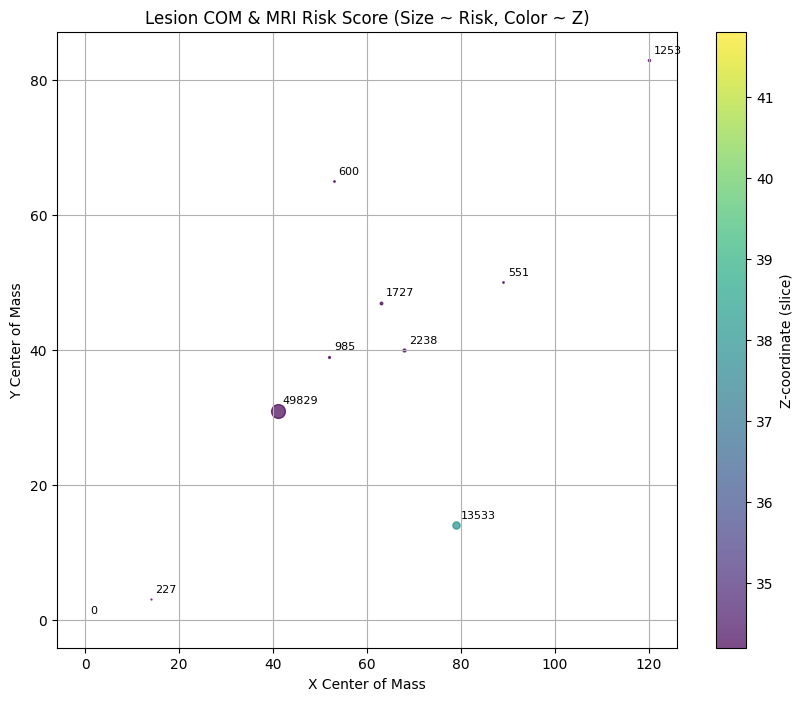

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your results
df = pd.read_csv('extracted_biomarkers_final.csv')

# Pick a few random examples
sample_df = df.sample(10, random_state=42)

plt.figure(figsize=(10, 8))
for idx, row in sample_df.iterrows():
    x, y, z = row['center_of_mass_x'], row['center_of_mass_y'], row['center_of_mass_z']
    risk = row['MRI_Risk_Score']
    plt.scatter(x, y, c=z, s=risk/500, cmap='viridis', alpha=0.7)  # size proportional to risk
    plt.text(x+1, y+1, f"{risk:.0f}", fontsize=8)

plt.colorbar(label='Z-coordinate (slice)')
plt.xlabel('X Center of Mass')
plt.ylabel('Y Center of Mass')
plt.title('Lesion COM & MRI Risk Score (Size ~ Risk, Color ~ Z)')
plt.grid(True)
plt.show()
